## Recurrent model stock prediction: GRU vs LSTM vs RNN
*   RNN: simple, but struggles with long-term dependencies
*   LSTM: adds memory gates, better at handling long sequences
*   GRU: simpler than lstm, still handles longer context well, fewer parameters

This code is for Gated Recurrent Unit showing its balance between simplicity and performance


In [87]:
# 1: libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import math
import time

In [88]:
# 2: load data
df = pd.read_csv('AAPL.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date') # sort before setting index or use index later

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

df.head()

Using device: cpu


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [89]:
# 3: feature engineering, match LSTM
# calculate time difference between consecutive days, using index after setting it
df['TimeDiff'] = df['Date'].diff().dt.days.fillna(0).astype(int)

df['SMA_5'] = df['Close'].rolling(window=5).mean()  # 5-day Simple Moving Average
df['SMA_10'] = df['Close'].rolling(window=10).mean() # 10-day Simple Moving Average
df['SMA_20'] = df['Close'].rolling(window=20).mean() # 20-day Simple Moving Average
df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()  # 5-day Exponential Moving Average
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['Rolling_SD_5'] = df['Close'].rolling(window=5).std()  # 5-day Rolling Standard Deviation
df['Rolling_SD_10'] = df['Close'].rolling(window=10).std() # 10-day Rolling Standard Deviation
df['Rolling_SD_20'] = df['Close'].rolling(window=20).std() # 20-day Rolling Standard Deviation
df['Range'] = df['High'] - df['Low']             # Daily range
df['Body'] = df['Close'] - df['Open']            # Candle body
# ensure Open is not zero before calculating Pct_Change
# add small epsilon to avoid division by zero if Open can be 0
epsilon = 1e-9
df['Pct_Change'] = (df['Close'] - df['Open']) / (df['Open'] + epsilon) # % change
df['ExpandingMean'] = df['Close'].expanding().mean()
df['ExpandingStd'] = df['Close'].expanding().std()

# drop rows with NaN values created by rolling/expanding windows
df.dropna(inplace=True)
print(f"Shape after feature engineering & dropping NaNs: {df.shape}")
print(df.head())
print(df.describe())

Shape after feature engineering & dropping NaNs: (9890, 22)
         Date      Open      High       Low     Close  Adj Close   Volume  \
19 1981-01-12  0.569196  0.569196  0.564732  0.564732   0.447460  5924800   
20 1981-01-13  0.546875  0.546875  0.544643  0.544643   0.431542  5762400   
21 1981-01-14  0.546875  0.549107  0.546875  0.546875   0.433311  3572800   
22 1981-01-15  0.558036  0.562500  0.558036  0.558036   0.442154  3516800   
23 1981-01-16  0.555804  0.555804  0.553571  0.553571   0.438617  3348800   

    TimeDiff     SMA_5    SMA_10  ...    EMA_10    EMA_20  Rolling_SD_5  \
19         3  0.560268  0.589955  ...  0.570814  0.561104      0.014380   
20         1  0.554018  0.580134  ...  0.566056  0.559536      0.012568   
21         1  0.553125  0.572098  ...  0.562568  0.558330      0.012958   
22         1  0.556696  0.566964  ...  0.561744  0.558302      0.010775   
23         1  0.553571  0.560714  ...  0.560258  0.557851      0.008201   

    Rolling_SD_10  Rolling

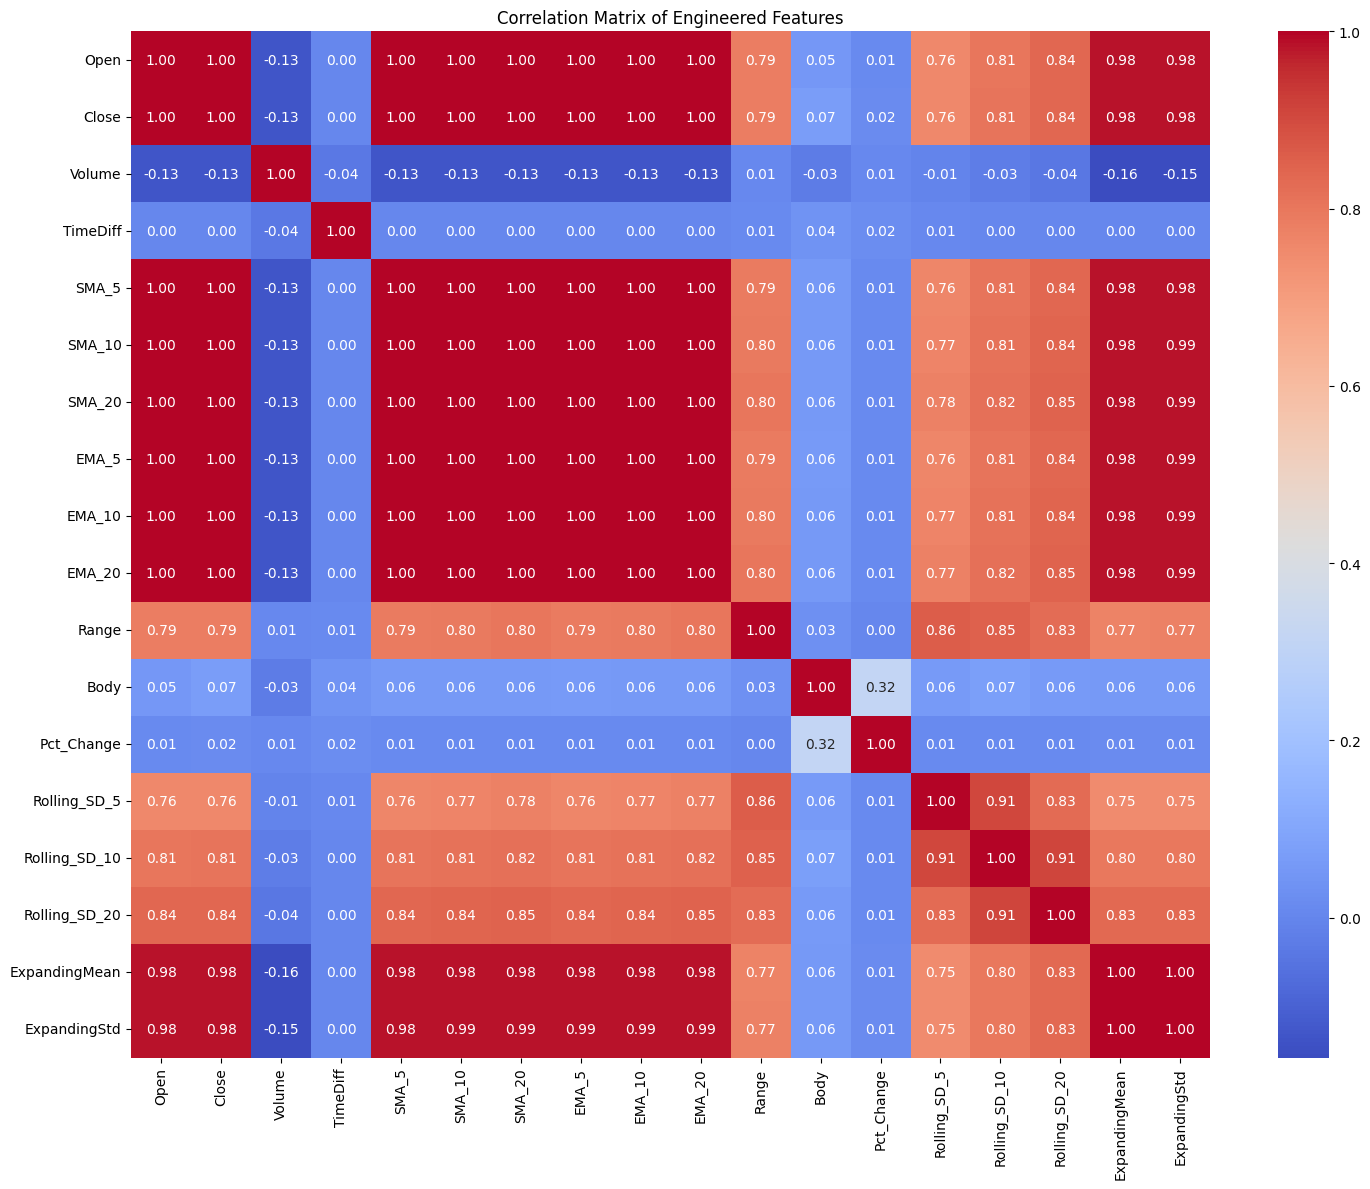

In [90]:
# 4: correlation matrix
features_for_corr = ['Open', 'Close', 'Volume', 'TimeDiff',
                     'SMA_5', 'SMA_10', 'SMA_20',
                     'EMA_5', 'EMA_10', 'EMA_20',
                     'Range', 'Body', 'Pct_Change',
                     'Rolling_SD_5', 'Rolling_SD_10', 'Rolling_SD_20',
                     'ExpandingMean', 'ExpandingStd']

# check if all columns exist before calculating correlation
existing_features_for_corr = [col for col in features_for_corr if col in df.columns]
corr_matrix = df[existing_features_for_corr].corr()

plt.figure(figsize=(15, 12)) # increase size for more features
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=False)
plt.title('Correlation Matrix of Engineered Features')
plt.tight_layout()
plt.show()

In [91]:
# 5: define features (X) and target (y) - Close
feature_columns = ['Open', 'Volume', 'TimeDiff',
                   'SMA_5', 'SMA_10', 'SMA_20',
                   'EMA_5', 'EMA_10', 'EMA_20',
                   'Range', 'Body', 'Pct_Change',
                   'Rolling_SD_5', 'Rolling_SD_10', 'Rolling_SD_20',
                   'ExpandingMean', 'ExpandingStd'] # 17 features
target_column = 'Close'

# check all selected feature columns exist in dataframe
feature_columns = [col for col in feature_columns if col in df.columns]
print(f"Using {len(feature_columns)} features for input X: {feature_columns}")

X = df[feature_columns].values
y = df[target_column].values

Using 17 features for input X: ['Open', 'Volume', 'TimeDiff', 'SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'EMA_20', 'Range', 'Body', 'Pct_Change', 'Rolling_SD_5', 'Rolling_SD_10', 'Rolling_SD_20', 'ExpandingMean', 'ExpandingStd']


In [93]:
# 6: data split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler() # separate scaler for target

# scale features (X)
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# scale target (y)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

print("Features and target scaled using MinMaxScaler.")

X_train shape: (7912, 17), y_train shape: (7912,)
X_test shape: (1978, 17), y_test shape: (1978,)
Features and target scaled using MinMaxScaler.


In [101]:
# 7: create sequences and split train/val
SEQ_LENGTH = 60

def create_sequences(X_data, y_data, seq_length):
    Xs, ys = [], []
    for i in range(len(X_data) - seq_length):
        Xs.append(X_data[i:(i+seq_length)])
        ys.append(y_data[i+seq_length])
    # convert to numpy arrays first before creating tensors
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, SEQ_LENGTH)

# split training into train/val
val_split_pct = 0.10
val_size = int(val_split_pct * len(X_train_seq))
train_size = len(X_train_seq) - val_size

X_val_seq = X_train_seq[train_size:] # split off last val_size for validation
y_val_seq = y_train_seq[train_size:]
X_train_seq = X_train_seq[:train_size] # keep first part as new training set
y_train_seq = y_train_seq[:train_size]

print(f"Shapes after splitting sequences (Effective split ~{100*train_size/len(df):.0f}% Train / ~{100*val_size/len(df):.0f}% Val / ~{100*len(X_test_seq)/len(df):.0f}% Test):")
print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"y_train_seq shape: {y_train_seq.shape}")
print(f"X_val_seq shape:   {X_val_seq.shape}")
print(f"y_val_seq shape:   {y_val_seq.shape}")
print(f"X_test_seq shape:  {X_test_seq.shape}")

X_train_tensor = torch.from_numpy(X_train_seq).float().to(device)
y_train_tensor = torch.from_numpy(y_train_seq).float().to(device)
X_val_tensor = torch.from_numpy(X_val_seq).float().to(device)
y_val_tensor = torch.from_numpy(y_val_seq).float().to(device)
X_test_tensor = torch.from_numpy(X_test_seq).float().to(device)
y_test_tensor = torch.from_numpy(y_test_seq).float().to(device)

print("\nTensor shapes after seq creation and val split:")
print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"X_val_tensor shape:   {X_val_tensor.shape}")
print(f"y_val_tensor shape:   {y_val_tensor.shape}")
print(f"X_test_tensor shape:  {X_test_tensor.shape}")
print(f"y_test_tensor shape:  {y_test_tensor.shape}")

Shapes after splitting sequences (Effective split ~71% Train / ~8% Val / ~19% Test):
X_train_seq shape: (7067, 60, 17)
y_train_seq shape: (7067, 1)
X_val_seq shape:   (785, 60, 17)
y_val_seq shape:   (785, 1)
X_test_seq shape:  (1918, 60, 17)

Tensor shapes after seq creation and val split:
X_train_tensor shape: torch.Size([7067, 60, 17])
y_train_tensor shape: torch.Size([7067, 1])
X_val_tensor shape:   torch.Size([785, 60, 17])
y_val_tensor shape:   torch.Size([785, 1])
X_test_tensor shape:  torch.Size([1918, 60, 17])
y_test_tensor shape:  torch.Size([1918, 1])


In [102]:
# 8: GRUmodel
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_prob):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.dropout(out[:, -1, :]) # output of last time step
        out = self.fc(out)
        return out

INPUT_SIZE = X_train_tensor.shape[2] # 17
HIDDEN_SIZE = 200
NUM_LAYERS = 1
OUTPUT_SIZE = 1
DROPOUT_PROB = 0.2

model = GRUModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE, DROPOUT_PROB).to(device)
print("\nGRU Model Architecture:")
print(model)


GRU Model Architecture:
GRUModel(
  (gru): GRU(17, 200, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=200, out_features=1, bias=True)
)


In [103]:
# 9: training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5, verbose=True)

NUM_EPOCHS = 500
BATCH_SIZE = 64 # DataLoader for batches vs. full pass
CLIP_VALUE = 10.0
EARLY_STOPPING_PATIENCE = 10

print("\nTraining Setup:")
print(f"Criterion: {criterion}")
print(f"Optimizer: Adam (lr={optimizer.defaults['lr']}, weight_decay={optimizer.defaults['weight_decay']})")
print(f"Scheduler: ReduceLROnPlateau (patience={scheduler.patience})")
print(f"Max Epochs: {NUM_EPOCHS}, Batch Size: {BATCH_SIZE}, Early Stopping Patience: {EARLY_STOPPING_PATIENCE}, Grad Clip: {CLIP_VALUE}")



Training Setup:
Criterion: MSELoss()
Optimizer: Adam (lr=0.0005, weight_decay=0.0001)
Scheduler: ReduceLROnPlateau (patience=5)
Max Epochs: 500, Batch Size: 64, Early Stopping Patience: 10, Grad Clip: 10.0


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [104]:
# 10: training loop
train_losses = []
val_losses = []
best_val_loss = float('inf')
epochs_no_improve = 0
start_time = time.time()

# DataLoader
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("\nStarting Training")
for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_VALUE) # Grad Clipping
        optimizer.step()
        epoch_train_loss += loss.item()
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # validation phase (using test set)
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            epoch_val_loss += loss.item()
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss) # LR scheduling step

    # progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | LR: {optimizer.param_groups[0]["lr"]:.6f}')

    # early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # torch.save(model.state_dict(), 'gru_engineered_best_val_loss.pth') # can save best model
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f'\nEarly stopping triggered after epoch {epoch + 1}. Best Val Loss: {best_val_loss:.6f}')
            break

end_time = time.time()
training_time = end_time - start_time
print(f"\nTotal Training Time: {training_time:.2f} seconds")


Starting Training
Epoch [1/500] | Train Loss: 0.000509 | Val Loss: 0.000626 | LR: 0.000500
Epoch [10/500] | Train Loss: 0.000025 | Val Loss: 0.000338 | LR: 0.000500
Epoch [20/500] | Train Loss: 0.000021 | Val Loss: 0.000405 | LR: 0.000125

Early stopping triggered after epoch 24. Best Val Loss: 0.000305

Total Training Time: 298.07 seconds


In [105]:
# 11: final model eval on test set
print("\nFinal model evaluation on test set")

model.eval()

# make predictions on test set
with torch.no_grad():
    test_predictions_scaled = model(X_test_tensor)

# inverse transform predictions and actual values
test_predictions = scaler_y.inverse_transform(test_predictions_scaled.cpu().numpy())
y_test_actual = scaler_y.inverse_transform(y_test_tensor.cpu().numpy())

# calculate evaluation metrics
mae = mean_absolute_error(y_test_actual, test_predictions)
r2 = r2_score(y_test_actual, test_predictions)
mse = mean_squared_error(y_test_actual, test_predictions)
rmse = math.sqrt(mse)

print(f"\nGRU Model Evaluation (Engineered Features):")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# calculate threshold accuracy
def accuracy_within_margin(actual, predicted, margin_percent):
    actual = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()
    epsilon = 1e-9 # small num to avoid division by zero
    error = np.abs((predicted - actual) / (actual + epsilon))
    threshold = margin_percent / 100.0
    accuracy = np.mean(error < threshold) * 100.0
    return accuracy

print("\nThreshold Accuracy:")
for pct in [1, 2, 5, 10]:
    acc = accuracy_within_margin(y_test_actual, test_predictions, pct)
    print(f"Accuracy within {pct}%: {acc:.2f}%")

print("\nPredicting Next Day's Price:")
model.eval()
last_sequence_features = df[feature_columns].values[-SEQ_LENGTH:]
last_sequence_scaled = scaler_X.transform(last_sequence_features)
last_sequence_tensor = torch.from_numpy(last_sequence_scaled).float().unsqueeze(0).to(device)
with torch.no_grad():
    scaled_prediction_next_day = model(last_sequence_tensor)
projected_price = scaler_y.inverse_transform(scaled_prediction_next_day.cpu().numpy())
final_predicted_price = projected_price[0][0]
last_actual_date = df['Date'].iloc[-1]
print(f"Based on data up to {last_actual_date.strftime('%Y-%m-%d')},")
print(f"The projected closing price for the next trading day is: ${final_predicted_price:.2f}")


Final model evaluation on test set

GRU Model Evaluation (Engineered Features):
Mean Absolute Error (MAE): 4.6309
R-squared (R²): 0.9830
Mean Squared Error (MSE): 56.9703
Root Mean Squared Error (RMSE): 7.5479

Threshold Accuracy:
Accuracy within 1%: 24.30%
Accuracy within 2%: 44.16%
Accuracy within 5%: 82.48%
Accuracy within 10%: 98.64%

Predicting Next Day's Price:
Based on data up to 2020-04-01,
The projected closing price for the next trading day is: $232.74


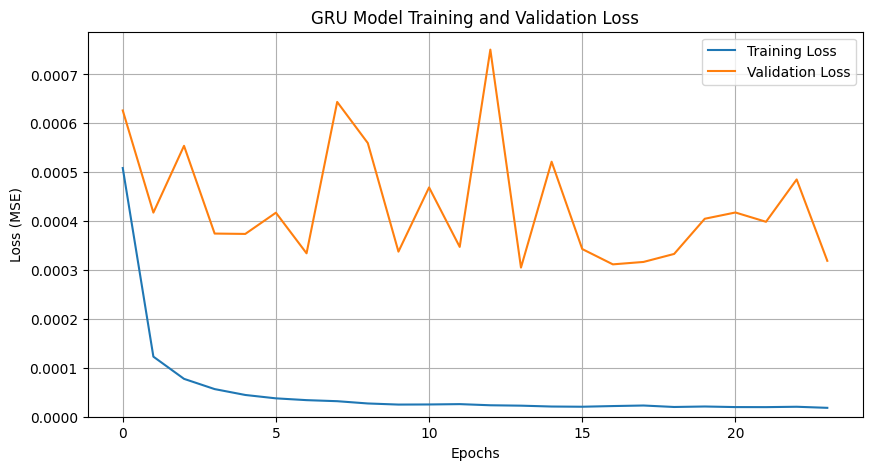

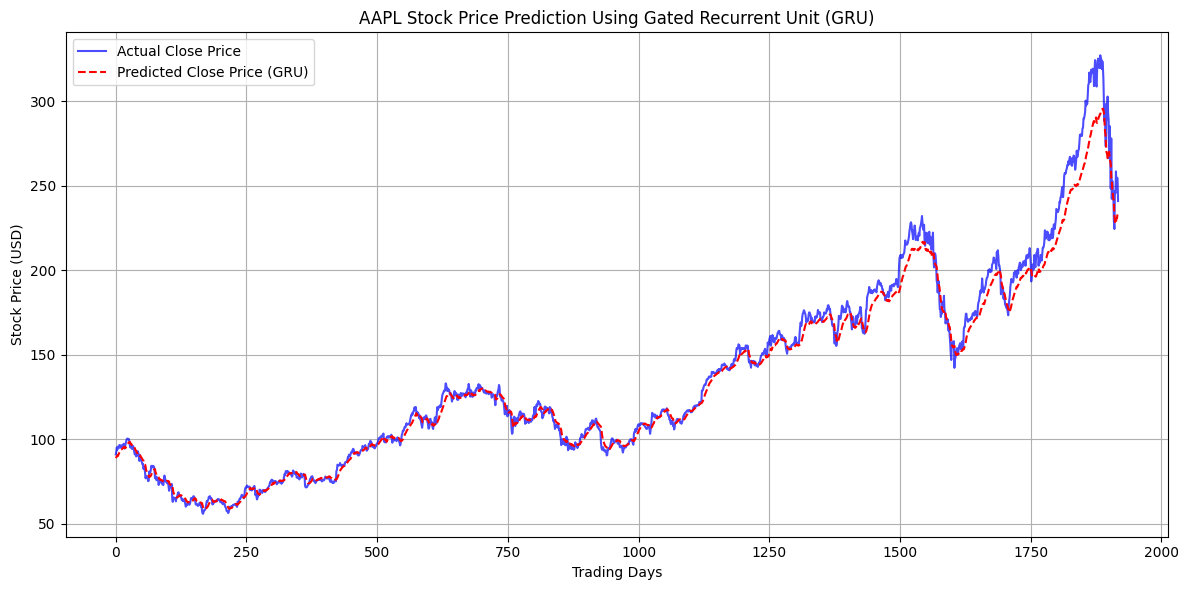


GRU Results Summary:
{
  "model_name": "GRU Results (Engineered Features):",
  "split": "72% Train Seq / 8% Val Seq / 20% Test Seq",
  "seq_length": 60,
  "mae": 4.630856513977051,
  "r2": 0.9830281734466553,
  "mse": 56.9703254699707,
  "rmse": 7.547868935664603,
  "training_time_seconds": 298.06581449508667,
  "epochs_ran": 24,
  "best_val_loss": 0.0003050168147288227,
  "threshold_accuracy": {
    "1": 24.29614181438999,
    "2": 44.16058394160584,
    "5": 82.48175182481752,
    "10": 98.6444212721585
  }
}


In [109]:
# 12: results
# training & validation Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('GRU Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.show()

# actual vs predicted prices (test set)
plt.figure(figsize=(12, 6))
plot_y_test_actual = y_test_actual
plot_test_predictions = test_predictions

plt.plot(plot_y_test_actual, label='Actual Close Price', color='blue', alpha=0.7)
plt.plot(plot_test_predictions, label='Predicted Close Price (GRU)', color='red', linestyle='--')
plt.title('AAPL Stock Price Prediction Using Gated Recurrent Unit (GRU)')
plt.xlabel('Trading Days')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# calculate split percentages based on seq counts
total_sequences = len(X_train_seq) + len(X_val_seq) + len(X_test_seq)
train_seq_pct = 100 * len(X_train_seq) / total_sequences
val_seq_pct = 100 * len(X_val_seq) / total_sequences
test_seq_pct = 100 * len(X_test_seq) / total_sequences
split_description = f"{train_seq_pct:.0f}% Train Seq / {val_seq_pct:.0f}% Val Seq / {test_seq_pct:.0f}% Test Seq"

# test set eval
results_summary = {
  "model_name": "GRU Results (Engineered Features):",
  "split": split_description,
  "seq_length": SEQ_LENGTH,
  "mae": mae,
  "r2": r2,
  "mse": mse,
  "rmse": rmse,
  "training_time_seconds": training_time,
  "epochs_ran": epoch + 1 if 'epoch' in locals() else 0,
  "best_val_loss": best_val_loss, # best loss on val set
  "threshold_accuracy": {
    str(pct): accuracy_within_margin(y_test_actual, test_predictions, pct) for pct in [1, 2, 5, 10]
  }
}

print("\nGRU Results Summary:")
import json
print(json.dumps(results_summary, indent=2))